In [20]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import torch
import torch_geometric as pyg
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

from bipartite_gnn.graph_visualizatons import visualize_graph, visualize_embeddings
from baseline_evals.feature_selection import variance_filtering, class_variational_selection
from baseline_evals.knn_eval import knn_eval
from baseline_evals.svm_eval import svm_eval
from baseline_evals.xgboost_eval import xgboost_eval
from baseline_evals.mlp_eval import mlp_eval

from gnn_experiments.mogonet_eval import mogonet_eval
from gnn_experiments.bipartite_eval import bipartite_eval

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
null_vals = ["NA"]
mrna = pl.read_csv("BRCA_PROCESSED_DATA/mrna.tsv", separator="\t", null_values=null_vals)
cna = pl.read_csv("BRCA_PROCESSED_DATA/cnvth.tsv", separator="\t", null_values=null_vals)
mirna = pl.read_csv("BRCA_PROCESSED_DATA/mirna.tsv", separator="\t", null_values=null_vals)
meth = pl.read_csv("BRCA_PROCESSED_DATA/meth.tsv", separator="\t", null_values=null_vals)

labels = pl.read_csv("BRCA_PROCESSED_DATA/labels.tsv", separator="\t")
le = LabelEncoder()
le.fit(labels["PAM50_mRNA_nature2012"].to_list())
y = le.transform(labels["PAM50_mRNA_nature2012"].to_list())

# ensure that the omic channels are alined with the labels and with each other
assert mrna.columns[1:] == cna.columns[1:] == mirna.columns[1:] == labels["sampleID"].to_list()

In [26]:
X_mrna = mrna[:,1:].to_numpy().T
X_cna = cna[:,1:].to_numpy().T
X_mirna = mirna[:,1:].to_numpy().T
X_meth = meth[:,1:].to_numpy().T

X = np.hstack([X_mrna, X_cna, X_mirna, X_meth])

X_mrna.shape, X_cna.shape, X_mirna.shape, X_meth.shape, y.shape

((483, 18975), (483, 24776), (483, 231), (483, 9317), (483,))

In [93]:
knn_eval(X, y, select_n_features=True, nn_range=(1, 100))

500
| KNN | 0.64 +/- 0.05 | 0.55 +/- 0.04 | 0.60 +/- 0.05 |
study.best_value=0.6030539234584164, study.best_params={'n_neighbors': 1, 'n_features': 1740}


In [94]:
svm_eval(X, y, select_n_features=True, verbose=True, n_trials=25, n_features_preselect=5000)

Trial 1 / 25
ConvergenceWarning occurred during fitting.
Trial 2 / 25
ConvergenceWarning occurred during fitting.
Trial 3 / 25
ConvergenceWarning occurred during fitting.
Trial 4 / 25
ConvergenceWarning occurred during fitting.
Trial 5 / 25
ConvergenceWarning occurred during fitting.
Trial 6 / 25
ConvergenceWarning occurred during fitting.
Trial 7 / 25
ConvergenceWarning occurred during fitting.
Trial 8 / 25
ConvergenceWarning occurred during fitting.
Trial 9 / 25
ConvergenceWarning occurred during fitting.
Trial 10 / 25
ConvergenceWarning occurred during fitting.
Trial 11 / 25
| SVM | 0.70 +/- 0.03 | 0.69 +/- 0.02 | 0.70 +/- 0.03 |
Trial 12 / 25
Trial 13 / 25
Trial 14 / 25
| SVM | 0.73 +/- 0.03 | 0.72 +/- 0.03 | 0.73 +/- 0.04 |
Trial 15 / 25
ConvergenceWarning occurred during fitting.
Trial 16 / 25
ConvergenceWarning occurred during fitting.
Trial 17 / 25
| SVM | 0.77 +/- 0.02 | 0.76 +/- 0.03 | 0.76 +/- 0.03 |
Trial 18 / 25
ConvergenceWarning occurred during fitting.
Trial 19 / 25
| S

{'acc': 0.7681056701030927,
 'f1_macro': 0.7604126033878549,
 'f1_weighted': 0.7645802382377522,
 'acc_std': 0.02509263990853465,
 'f1_macro_std': 0.027788541496390276,
 'f1_weighted_std': 0.02796289174756003}

In [95]:
xgboost_eval(X, y, verbose=True, n_trials=40)

0 / 40
 XGBoost val | 0.61 +/- 0.08 | 0.52 +/- 0.08 | 0.61 +/- 0.08 |
| XGBoost | 0.59 +/- 0.06 | 0.53 +/- 0.06 | 0.59 +/- 0.05 |
1 / 40
2 / 40
 XGBoost val | 0.66 +/- 0.09 | 0.57 +/- 0.07 | 0.65 +/- 0.09 |
| XGBoost | 0.61 +/- 0.06 | 0.53 +/- 0.05 | 0.60 +/- 0.05 |
3 / 40
Pruning trial
4 / 40
5 / 40
 XGBoost val | 0.65 +/- 0.04 | 0.57 +/- 0.06 | 0.64 +/- 0.05 |
| XGBoost | 0.62 +/- 0.04 | 0.55 +/- 0.05 | 0.61 +/- 0.05 |
6 / 40
7 / 40
 XGBoost val | 0.66 +/- 0.05 | 0.58 +/- 0.02 | 0.65 +/- 0.04 |
| XGBoost | 0.62 +/- 0.03 | 0.56 +/- 0.03 | 0.61 +/- 0.03 |
8 / 40
9 / 40
 XGBoost val | 0.64 +/- 0.08 | 0.55 +/- 0.08 | 0.63 +/- 0.08 |
| XGBoost | 0.62 +/- 0.05 | 0.55 +/- 0.06 | 0.61 +/- 0.05 |
10 / 40
 XGBoost val | 0.78 +/- 0.08 | 0.73 +/- 0.08 | 0.78 +/- 0.08 |
| XGBoost | 0.75 +/- 0.05 | 0.74 +/- 0.05 | 0.74 +/- 0.05 |
11 / 40
12 / 40
13 / 40
14 / 40
15 / 40
16 / 40
17 / 40
18 / 40
19 / 40
20 / 40
21 / 40
22 / 40
23 / 40
24 / 40
25 / 40
26 / 40
27 / 40
28 / 40
Pruning trial
29 / 40
30 /

{'acc': 0.7453178694158076,
 'f1_macro': 0.7362298119895925,
 'f1_weighted': 0.7430950656540676,
 'acc_std': 0.048735728483881524,
 'f1_macro_std': 0.04884054577952907,
 'f1_weighted_std': 0.05191015905609542,
 'acc_val': 0.7791666666666667,
 'acc_val_std': 0.07523112535528244,
 'f1_macro_val': 0.7342949236753584,
 'f1_macro_val_std': 0.08306821526495713,
 'f1_weighted_val': 0.7768301734497387,
 'f1_weighted_val_std': 0.07630713600392763}

In [32]:
mlp_eval(X, y, n_trials=1, reg_type=None, n_evals=5, n_features=15000)

Trial 0 / 1
Fold 1 / 5
Fold 2 / 5
Fold 3 / 5
Fold 4 / 5
Fold 5 / 5
[0.83673471 0.81632656 0.81632656 0.9375     0.8125    ]
[0.81959052 0.81262596 0.80173341 0.95255814 0.82542088]
[0.83615944 0.81656279 0.81075001 0.93802326 0.81090067]
New best results
{'acc': 0.8438775658607482, 'f1_macro': 0.8423857817500691, 'f1_weighted': 0.842479234437708, 'acc_std': 0.04757908821380108, 'f1_macro_std': 0.05564825697536264, 'f1_weighted_std': 0.04867075300077522}
study.best_value=2.528742582048525, study.best_params={}
| MLP regularization : None | 0.84 +/- 0.05 | 0.84 +/- 0.06 | 0.84 +/- 0.05 |


In [33]:
mlp_eval(X, y, n_trials=1, reg_type="l1", n_evals=5, n_features=15000)

Trial 0 / 1
Fold 1 / 5
Fold 2 / 5
Fold 3 / 5
Fold 4 / 5
Fold 5 / 5
[0.75510204 0.91836733 0.75510204 0.95833331 0.79166669]
[0.71327058 0.87513843 0.73848901 0.96355499 0.80914682]
[0.75392682 0.91375686 0.74780118 0.95817349 0.79056157]
New best results
{'acc': 0.8357142806053162, 'f1_macro': 0.8199199637108571, 'f1_weighted': 0.8328439848195861, 'acc_std': 0.0857948843589885, 'f1_macro_std': 0.09143440376226275, 'f1_weighted_std': 0.08660528642429888}
study.best_value=2.488478229135759, study.best_params={}
| MLP regularization : l1 | 0.84 +/- 0.09 | 0.82 +/- 0.09 | 0.83 +/- 0.09 |


In [ ]:
[0.81632656 0.93877554 0.67346936 0.95833331 0.83333331]
[0.80772727 0.9271978  0.66870748 0.96640316 0.82681624]
[0.81721707 0.93937355 0.65750382 0.95734519 0.83376068]

In [34]:
mlp_eval(X, y, n_trials=1, reg_type="inner_mat", n_evals=5, n_features=15000)

Trial 0 / 1
Fold 1 / 5
Fold 2 / 5
Fold 3 / 5
Fold 4 / 5
Fold 5 / 5
[0.83673471 0.83673471 0.79591835 0.89583331 0.85416669]
[0.81959052 0.82904412 0.8037613  0.9178744  0.85600289]
[0.83615944 0.83103241 0.78357148 0.89472625 0.85338745]
New best results
{'acc': 0.8438775539398193, 'f1_macro': 0.845254643321408, 'f1_weighted': 0.839775406169529, 'acc_std': 0.032271948359728124, 'f1_macro_std': 0.04008061721156874, 'f1_weighted_std': 0.035925697695618514}
study.best_value=2.5289076034307563, study.best_params={}
| MLP regularization : inner_mat | 0.84 +/- 0.03 | 0.85 +/- 0.04 | 0.84 +/- 0.04 |


In [56]:
X.shape

(483, 231)

- for different omics different learning rates are more useful, for example for meth and (cna?) 1e-3 works and 1e-4 fails, while for mrna 1e-4 works better than 1e-3

In [18]:
val, test = mogonet_eval(
    n_splits=5,
    input_omics={
        "mrna": mrna,
        "mirna": mirna,
        # "cna": cna,
        "meth": meth,
    },
    n_input_features={
        "mrna": 200,
        "mirna": 200,
        # "circrna": 69,
        # "pirna": 219,
        # "te_counts": 600,
        # "cna": 200,
        "meth": 200,
    },
    mrmr_selection_params={
        'mrmr_path' : "BRCA_PROCESSED_DATA/mrmr_selected",
    },
    y=y,
    params={
        "encoder_hidden_channels": {
            "mrna": 200,
            "mirna": 200,
            # "cna": 200,
            "meth": 200,
        },
        "encoder_type": "gat",
        "num_classes": 4,
        "graph_style": "threshold",
        "avg_degree": 10,
        # "graph_style": "knn",
        # "knn": 10,
        "dropout": 0.05,
        "epochs": 300,
        "log_interval": 50,
        "save_best_model": False,
        "integrator_type": "attention",
        "integration_dim": 4,
        "self_connections": True,
    }
)

print(f"| MOGONET GAT (mirna only) val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
print(f"| MOGONET GAT (mirna only) test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

Fold 1 / 5
Loading BRCA_PROCESSED_DATA/mrmr_selected/mrna/mrna_fold_0.csv
Loading BRCA_PROCESSED_DATA/mrmr_selected/mirna/mirna_fold_0.csv
Loading BRCA_PROCESSED_DATA/mrmr_selected/meth/meth_fold_0.csv
Epoch: 050:
Train Loss: 0.3126, Train Acc: 0.8679, Train F1 Macro: 0.8683, Train F1 Weighted: 0.8694
Val Loss: 0.2344, Val Acc: 0.8542, Val F1 Macro: 0.8631, Val F1 Weighted: 0.8562
Test Loss: 0.2720, Test Acc: 0.8776, Test F1 Macro: 0.8734, Test F1 Weighted: 0.8749
##################################################
Epoch: 100:
Train Loss: 0.1560, Train Acc: 0.9352, Train F1 Macro: 0.9267, Train F1 Weighted: 0.9367
Val Loss: 0.2180, Val Acc: 0.8958, Val F1 Macro: 0.9060, Val F1 Weighted: 0.8984
Test Loss: 0.3212, Test Acc: 0.8571, Test F1 Macro: 0.8435, Test F1 Weighted: 0.8564
##################################################
Epoch: 150:
Train Loss: 0.0932, Train Acc: 0.9689, Train F1 Macro: 0.9634, Train F1 Weighted: 0.9692
Val Loss: 0.2460, Val Acc: 0.8958, Val F1 Macro: 0.9003, Val 

In [ ]:
val, test

- all
| MOGONET GAT (mirna only) val | 0.90 +/- 0.03 | 0.90 +/- 0.03 | 0.90 +/- 0.03 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.03 | 0.87 +/- 0.05 | 0.88 +/- 0.03 |

- mrna only w vcdn
| MOGONET GAT (mirna only) val | 0.88 +/- 0.06 | 0.88 +/- 0.06 | 0.88 +/- 0.05 |
| MOGONET GAT (mirna only) test | 0.90 +/- 0.03 | 0.90 +/- 0.04 | 0.90 +/- 0.03 |

- mrna only w/o vcdn
| MOGONET GAT (mirna only) val | 0.89 +/- 0.05 | 0.89 +/- 0.05 | 0.89 +/- 0.05 |
| MOGONET GAT (mirna only) test | 0.90 +/- 0.02 | 0.89 +/- 0.03 | 0.90 +/- 0.02 |

- mrna, mirna, meth, vcdn
| MOGONET GAT (mirna only) val | 0.86 +/- 0.04 | 0.85 +/- 0.05 | 0.86 +/- 0.04 |
| MOGONET GAT (mirna only) test | 0.89 +/- 0.01 | 0.90 +/- 0.01 | 0.89 +/- 0.01 |

- mrna, mirna
| MOGONET GAT (mirna only) val | 0.82 +/- 0.05 | 0.80 +/- 0.05 | 0.82 +/- 0.05 |
| MOGONET GAT (mirna only) test | 0.91 +/- 0.02 | 0.91 +/- 0.02 | 0.91 +/- 0.02 |

| Omic combination | Accuracy | F1 macro | F1 weighted |
|------------------|----------|----------|-------------|
| mRNA, miRNA | 0.87 +/- 0.02 | 0.87 +/- 0.02 | 0.87 +/- 0.02 |
| mRNA, miRNA, CNA | 0.87 +/- 0.04 | 0.87 +/- 0.04 | 0.88 +/- 0.04 |
| mRNA, miRNA, Meth | 0.91 +/- 0.02 | 0.91 +/- 0.03 | 0.90 +/- 0.02 |
| mRNA, miRNA, Meth, CNA | 0.88 +/- 0.04 | 0.87 +/- 0.04 | 0.88 +/- 0.04 |


- mrna, mirna, cna
| MOGONET GAT (mirna only) val | 0.86 +/- 0.09 | 0.86 +/- 0.10 | 0.86 +/- 0.09 |
| MOGONET GAT (mirna only) test | 0.88 +/- 0.04 | 0.88 +/- 0.04 | 0.89 +/- 0.04 |

| MOGONET GAT | 0.87 +/- 0.04 | 0.87 +/- 0.04 | 0.88 +/- 0.04 |

- mrna, mirna, meth, cna, attention integration
| MOGONET GAT (mirna only) val | 0.88 +/- 0.04 | 0.87 +/- 0.04 | 0.88 +/- 0.04 |
| MOGONET GAT (mirna only) test | 0.86 +/- 0.05 | 0.85 +/- 0.06 | 0.86 +/- 0.06 |

- mrna, mirna, meth, attention integration
| MOGONET GAT (mirna only) val | 0.89 +/- 0.08 | 0.88 +/- 0.08 | 0.89 +/- 0.08 |
| MOGONET GAT (mirna only) test | 0.91 +/- 0.02 | 0.91 +/- 0.03 | 0.90 +/- 0.02 |

| MOGONET GCN (mirna only) val | 0.86 +/- 0.05 | 0.85 +/- 0.05 | 0.86 +/- 0.05 |
| MOGONET GCN (mirna only) test | 0.86 +/- 0.04 | 0.86 +/- 0.07 | 0.86 +/- 0.04 |

- attention combined with vcdn
| MOGONET GAT (mirna only) val | 0.87 +/- 0.02 | 0.86 +/- 0.02 | 0.87 +/- 0.02 |
| MOGONET GAT (mirna only) test | 0.86 +/- 0.03 | 0.85 +/- 0.03 | 0.87 +/- 0.03 |

- attnetion integrator, no vcdn, kaiming init for GAT layers
| MOGONET GAT (mirna only) val | 0.87 +/- 0.03 | 0.86 +/- 0.04 | 0.87 +/- 0.03 |
| MOGONET GAT (mirna only) test | 0.89 +/- 0.06 | 0.89 +/- 0.07 | 0.89 +/- 0.06 |

- thresholding works much better than knn

- bipartite network fails for meth because meth distribution is a mix of bnomial distributions, would need to use a different model for them, do small literature review on this

- same story for cna, which is categorical (e.g. -1, 0, 1, 2)

(483, 9317)


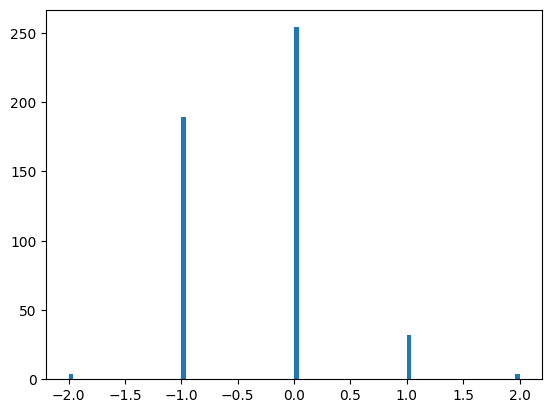

In [43]:
print(X_meth.shape)

# plot first feature

import matplotlib.pyplot as plt

plt.hist(X_cna[:, 100], bins=100)
plt.show()

In [19]:
proj_n_features = 100

val, test = bipartite_eval(
    n_splits=5,
    input_omics={
        "mrna": mrna,
        # "meth": meth,
        # "mirna": mirna,
        # "cna": cna,
    },
    n_input_features={
        "mrna": 200,
        # "meth": 200,
        # "mirna": 200,
        # "circrna": 69,
        # "pirna": 219,
        # "te_counts": 600,
        # "cna": 200,
    },
    multipliers={
        "mrna": 1.5,
        # "meth": 1.5,
        # "mirna": 1.3,
        # "cna": 1.0,
    },
    mrmr_selection_params={
        "mrmr_path": "BRCA_PROCESSED_DATA/mrmr_selected",
    },
    input_omics_interactions={
        # ("cna", "cna") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "Official Symbol Interactor A",
        #         "interactant_col_2" : "Official Symbol Interactor B",
        #         "interactions_file" : "biogrid_preprocessed_data.csv",
        #     },
        #     "protein_interaction" : {
        #         "interactant_col_1" : "gene1",
        #         "interactant_col_2" : "gene2",
        #         "interactions_file" : "string_db/ppi.csv",
        #     },
        # },
        ("mrna", "mrna") : {
            "gene_interaction" : {
                "interactant_col_1" : "Official Symbol Interactor A",
                "interactant_col_2" : "Official Symbol Interactor B",
                "interactions_file" : "biogrid_preprocessed_data.csv",
            },
            "protein_interaction" : {
                "interactant_col_1" : "gene1",
                "interactant_col_2" : "gene2",
                "interactions_file" : "string_db/ppi.csv",
            },
        },
        # ("meth", "meth") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "Official Symbol Interactor A",
        #         "interactant_col_2" : "Official Symbol Interactor B",
        #         "interactions_file" : "biogrid_preprocessed_data.csv",
        #     },
        #     "protein_interaction" : {
        #         "interactant_col_1" : "gene1",
        #         "interactant_col_2" : "gene2",
        #         "interactions_file" : "string_db/ppi.csv",
        #     },
        # },
        # ("mrna", "meth") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "Official Symbol Interactor A",
        #         "interactant_col_2" : "Official Symbol Interactor B",
        #         "interactions_file" : "biogrid_preprocessed_data.csv",
        #     },
        #     "protein_interaction" : {
        #         "interactant_col_1" : "gene1",
        #         "interactant_col_2" : "gene2",
        #         "interactions_file" : "string_db/ppi.csv",
        #     },
        # },
        # ("mrna", "mirna") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "gene",
        #         "interactant_col_2" : "mirna",
        #         "interactions_file" : "mirna_mrna_interactions_DB.csv",
        #     },
        # },
        # ("meth", "mirna") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "gene",
        #         "interactant_col_2" : "mirna",
        #         "interactions_file" : "mirna_mrna_interactions_DB.csv",
        #     },
        # }
    },
    y=y,
    params={
        "epochs": 600,
        "log_interval": 5,
        "save_best_model": False,
        "l1_lambda": 0.0,
        "hidden_channels": [proj_n_features, 100, 100, 8, 25],
        "heads": 2,
        "dropout": 0.05,
        "attention_dropout": 0.05,
        "integrator_type": "attention", # "attention",
        "three_layers": True,
        "proj_dim": proj_n_features,
        "use_proj_module": True,
    }
)

print(val)
print(test)

print("BipartiteGNN (mrna) results:")
print(f"| BipartiteGNN val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
print(f"| BipartiteGNN test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

dict_keys(['mrna'])
Fold 1 / 5
Projection dimension: 100
torch.Size([200]) torch.Size([200])
isolated sample nodes, isolated gene nodes, mean degree: 
tensor(11) tensor(0) tensor(24.6522)
Found 312.0 interactions
Found 990.0 interactions
HeteroData(
  omics=[1],
  feature_names=[1],
  y=[483],
  train_mask=[386],
  val_mask=[48],
  test_mask=[49],
  num_relations=3,
  mrna={ x=[483, 200] },
  mrna_feature={ x=[200, 100] },
  (mrna, diff_exp, mrna_feature)={
    edge_index=[2, 11907],
    edge_attr=[11907, 1],
  },
  (mrna_feature, interacts, mrna_feature)={ edge_index=[2, 1298] },
  (mrna_feature, rev_diff_exp, mrna)={
    edge_index=[2, 11907],
    edge_attr=[11907, 1],
  }
)
relations [('mrna', 'diff_exp', 'mrna_feature'), ('mrna_feature', 'interacts', 'mrna_feature'), ('mrna_feature', 'rev_diff_exp', 'mrna')]
creating projection layers
Epoch: 005:
Train Loss: 1.3829, Train Acc: 0.4249, Train F1 Macro: 0.2118, Train F1 Weighted: 0.3309
Val Loss: 1.3854, Val Acc: 0.4375, Val F1 Macro:

- bipartite not easily applicable to other omics such as meth since the distribution is a mix



- bipartite with vcdn and mirna mrna, 3-hop neighbourhood and projections

| Model | Accuracy | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| BipartiteGNN - projections | 0.76 +/- 0.08 | 0.75 +/- 0.09 | 0.75 +/- 0.09 |
| BipartiteGNN - feature selection | 0.86 +/- 0.07 | 0.85 +/- 0.07 | 0.85 +/- 0.07 |


| mRNA | 0.88 +/- 0.02 | 0.88 +/- 0.03 | 0.88 +/- 0.02 |
| mRNA, miRNA | 0.86 +/- 0.07 | 0.85 +/- 0.07 | 0.85 +/- 0.07 |
| mRNA, miRNA, CNA | 0.78 +/- 0.06 | 0.80 +/- 0.06 | 0.78 +/- 0.06 |


- bipartite with vcdn and mirna mrna, 3-hop neighbourhood
| BipartiteGNN test | 0.86 +/- 0.07 | 0.85 +/- 0.07 | 0.85 +/- 0.07 |

- biparitite with attention, mirna mrna, 3-hop neighbourhood
| BipartiteGNN test | 0.84 +/- 0.02 | 0.84 +/- 0.02 | 0.84 +/- 0.02 |

- bipartite mrna, mirna with attention, 2-hop neighbourhood, no interactions
| BipartiteGNN test | 0.81 +/- 0.05 | 0.80 +/- 0.05 | 0.81 +/- 0.05 |

- bipartite with vcdn, mirna mrna, 2-hop neighbourhood
| BipartiteGNN test | 0.84 +/- 0.02 | 0.83 +/- 0.02 | 0.84 +/- 0.02 |

- bipartite mrna, mirna with vcdn, 2-hop neighbourhood, no interactions
| BipartiteGNN val | 0.84 +/- 0.05 | 0.84 +/- 0.05 | 0.84 +/- 0.05 |

# Evals

### mrna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- |
| KNN | 0.84 +/- 0.02 | 0.83 +/- 0.03 | 0.84 +/- 0.02 |
| LIN SVM | 0.86 +/- 0.02 | 0.86 +/- 0.02 | 0.86 +/- 0.01 |
| XGBoost | 0.88 +/- 0.01 | 0.87 +/- 0.02 | 0.88 +/- 0.01 |
| MLP | 0.86 +/- 0.04 | 0.84 +/- 0.05 | 0.85 +/- 0.04 |
| MOGONET GCN | 0.82 +/- 0.03 | 0.80 +/- 0.04 | 0.81 +/- 0.03 |
| MOGONET GAT (mirna only) test | 0.90 +/- 0.02 | 0.89 +/- 0.03 | 0.90 +/- 0.02 |
| BipartiteGNN | 0.88 +/- 0.02 | 0.88 +/- 0.03 | 0.88 +/- 0.02 |

### mirna only
| Model | ACC | F1 macro | F1 weighted |
| --- | --- | --- | --- || LIN SVM | 0.80 +/- 0.03 | 0.78 +/- 0.05 | 0.79 +/- 0.03 |
| KNN | 0.70 +/- 0.03 | 0.63 +/- 0.06 | 0.67 +/- 0.04 |
| LIN SVM | 0.80 +/- 0.03 | 0.78 +/- 0.05 | 0.79 +/- 0.03 |
| XGBoost | 0.79 +/- 0.04 | 0.78 +/- 0.05 | 0.78 +/- 0.04 |
| MLP | 0.68 +/- 0.04 | 0.59 +/- 0.06 | 0.65 +/- 0.06 |
| MOGONET GAT | 0.74 +/- 0.05 | 0.73 +/- 0.08 | 0.74 +/- 0.05 |
| BipartiteGNN | 0.76 +/- 0.07 | 0.74 +/- 0.07 | 0.76 +/- 0.06 |

### meth only
| KNN | 0.64 +/- 0.05 | 0.55 +/- 0.04 | 0.60 +/- 0.05 |
| LIN SVM | 0.77 +/- 0.03 | 0.76 +/- 0.03 | 0.76 +/- 0.03 |
| XGBoost | 0.75 +/- 0.05 | 0.74 +/- 0.05 | 0.74 +/- 0.05 |
| MLP regularization : None | 0.43 +/- 0.05 | 0.17 +/- 0.02 | 0.28 +/- 0.00 |
| MOGONET GAT (mirna only) test | 0.73 +/- 0.02 | 0.68 +/- 0.04 | 0.73 +/- 0.02 |
| BipartiteGNN | - | - | - |


### cna only
| KNN | 0.70 +/- 0.03 | 0.63 +/- 0.05 | 0.67 +/- 0.04 |
| LIN SVM | 0.80 +/- 0.03 | 0.78 +/- 0.04 | 0.79 +/- 0.03 |
| XGBoost | 0.79 +/- 0.03 | 0.78 +/- 0.04 | 0.78 +/- 0.03 |
| MOGONET GAT | 0.66 +/- 0.05 | 0.64 +/- 0.04 | 0.66 +/- 0.05 |
| BipartiteGNN | 0.68 +/- 0.06 | 0.65 +/- 0.04 | 0.68 +/- 0.06 |

- bipartite params
params={
    "epochs": 600,
    "log_interval": 25,
    "save_best_model": False,
    "l1_lambda": 0.0,
    "hidden_channels": [proj_n_features, 70, 70, 4, 50],
    "heads": 2,
    "dropout": 0.05,
    "attention_dropout": 0.05,
    "integrator_type": None, # "vcdn",
    "three_layers": True,
    "proj_dim": proj_n_features,
    "use_proj_module": False,
}


In [ ]:
proj_n_features = 200

val, test = bipartite_eval(
    n_splits=5,
    input_omics={
        "mrna": mrna,
        # "meth": meth,
        # "mirna": mirna,
        # "cna": cna,
    },
    n_input_features={
        "mrna": proj_n_features,
        # "meth": 200,
        # "mirna": 200,
        # "circrna": 69,
        # "pirna": 219,
        # "te_counts": 600,
        # "cna": proj_n_features,
    },
    multipliers={
        "mrna": 1.3,
        # "meth": 1.3,
        # "mirna": 1.5,
        # "cna": 1.0,
    },
    mrmr_selection_params={
        "mrmr_path": "BRCA_PROCESSED_DATA/mrmr_selected",
    },
    input_omics_interactions={
        # ("cna", "cna") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "Official Symbol Interactor A",
        #         "interactant_col_2" : "Official Symbol Interactor B",
        #         "interactions_file" : "biogrid_preprocessed_data.csv",
        #     },
        #     "protein_interaction" : {
        #         "interactant_col_1" : "gene1",
        #         "interactant_col_2" : "gene2",
        #         "interactions_file" : "string_db/ppi.csv",
        #     },
        # },
        ("mrna", "mrna") : {
            "gene_interaction" : {
                "interactant_col_1" : "Official Symbol Interactor A",
                "interactant_col_2" : "Official Symbol Interactor B",
                "interactions_file" : "biogrid_preprocessed_data.csv",
            },
            "protein_interaction" : {
                "interactant_col_1" : "gene1",
                "interactant_col_2" : "gene2",
                "interactions_file" : "string_db/ppi.csv",
            },
        },
        # ("meth", "meth") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "Official Symbol Interactor A",
        #         "interactant_col_2" : "Official Symbol Interactor B",
        #         "interactions_file" : "biogrid_preprocessed_data.csv",
        #     },
        #     "protein_interaction" : {
        #         "interactant_col_1" : "gene1",
        #         "interactant_col_2" : "gene2",
        #         "interactions_file" : "string_db/ppi.csv",
        #     },
        # },
        # ("mrna", "meth") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "Official Symbol Interactor A",
        #         "interactant_col_2" : "Official Symbol Interactor B",
        #         "interactions_file" : "biogrid_preprocessed_data.csv",
        #     },
        #     "protein_interaction" : {
        #         "interactant_col_1" : "gene1",
        #         "interactant_col_2" : "gene2",
        #         "interactions_file" : "string_db/ppi.csv",
        #     },
        # },
        # ("mrna", "mirna") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "gene",
        #         "interactant_col_2" : "mirna",
        #         "interactions_file" : "mirna_mrna_interactions_DB.csv",
        #     },
        # },
        # ("meth", "mirna") : {
        #     "gene_interaction" : {
        #         "interactant_col_1" : "gene",
        #         "interactant_col_2" : "mirna",
        #         "interactions_file" : "mirna_mrna_interactions_DB.csv",
        #     },
        # }
    },
    y=y,
    params={
        "epochs": 600,
        "log_interval": 25,
        "save_best_model": False,
        "l1_lambda": 0.0,
        "hidden_channels": [proj_n_features, 70, 70, 4, 50],
        "heads": 2,
        "dropout": 0.05,
        "attention_dropout": 0.05,
        "integrator_type": None, # "attention",
        "three_layers": True,
        "proj_dim": proj_n_features,
        "use_proj_module": False,
    }
)

print(val)
print(test)

print("BipartiteGNN (mrna) results:")
print(f"| BipartiteGNN val | {val[:, 0].mean():.2f} +/- {val[:, 0].std():.2f} | {val[:, 1].mean():.2f} +/- {val[:, 1].std():.2f} | {val[:, 2].mean():.2f} +/- {val[:, 2].std():.2f} |")
print(f"| BipartiteGNN test | {test[:, 0].mean():.2f} +/- {test[:, 0].std():.2f} | {test[:, 1].mean():.2f} +/- {test[:, 1].std():.2f} | {test[:, 2].mean():.2f} +/- {test[:, 2].std():.2f} |")

dict_keys(['mrna'])
Fold 1 / 5
Projection dimension: 200
torch.Size([200]) torch.Size([200])
isolated sample nodes, isolated gene nodes, mean degree: 
tensor(0) tensor(0) tensor(34.3106)
Found 312.0 interactions
Found 990.0 interactions
HeteroData(
  omics=[1],
  feature_names=[1],
  y=[483],
  train_mask=[386],
  val_mask=[48],
  test_mask=[49],
  num_relations=3,
  mrna={ x=[483, 200] },
  mrna_feature={ x=[200, 200] },
  (mrna, diff_exp, mrna_feature)={
    edge_index=[2, 16572],
    edge_attr=[16572, 1],
  },
  (mrna_feature, interacts, mrna_feature)={ edge_index=[2, 1298] },
  (mrna_feature, rev_diff_exp, mrna)={
    edge_index=[2, 16572],
    edge_attr=[16572, 1],
  }
)
relations [('mrna', 'diff_exp', 'mrna_feature'), ('mrna_feature', 'interacts', 'mrna_feature'), ('mrna_feature', 'rev_diff_exp', 'mrna')]
Epoch: 025:
Train Loss: 1.2176, Train Acc: 0.1865, Train F1 Macro: 0.1679, Train F1 Weighted: 0.1421
Val Loss: 1.2698, Val Acc: 0.2083, Val F1 Macro: 0.1625, Val F1 Weighted: 0.